# McGinley Dynamic — does the 'auto-adjusting' line really hug price better?
### John McGinley's self-adjusting moving average, turned into a timing rule and tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cuts_whipsaws_%26_beats_a_plain_MA%3F: Mixed](https://img.shields.io/badge/Cuts_whipsaws_%26_beats_a_plain_MA%3F-Mixed-8b949e?style=flat-square)

Here's a pitch you'll meet on almost every charting platform's indicator list: plot the **McGinley Dynamic** instead of a plain moving average. Its formula has a built-in "speed dial" that supposedly makes it track price more tightly than a fixed SMA or EMA — no re-optimizing, no whipsaws, a moving average that "adjusts itself for you." Sounds great. Does the dial actually turn the right way — and does it beat just buying and holding?

> This is the plain-language layer. Want the *t*-stats, the mechanism math and the cost sweeps? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mcginley_dynamic import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE"]
ASOF = data.AS_OF
MD_N = 14

def _have_cache():
    return all(os.path.exists(data._cache_path(t)) for t in TICKERS)

HAVE_REAL = _have_cache()

def tape(t):
    return data.load_real(t, fetch=False, asof=ASOF)

print("real daily cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_spy': 8411, 'yrs': 33.4, 'md_n': 14, 'td_md': 1.981, 'td_sma': 1.535, 'td_ema': 1.327, 'step_price': 120.0, 'step_md': 104.04, 'step_sma': 108.57, 'step_ema': 111.52, 'step_pct_md': 20.2, 'step_pct_sma': 42.9, 'step_pct_ema': 57.6, 'md_sharpe': 0.38, 'md_cagr': 3.81, 'md_dd': -49.1, 'sma_sharpe': 0.238, 'sma_cagr': 2.07, 'sma_dd': -57.6, 'ema_sharpe': 0.267, 'ema_cagr': 2.4, 'ema_dd': -48.0, 'bh_sharpe': 0.647, 'bh_cagr': 10.83, 'bh_dd': -55.2, 'md_spread': -3.01, 'md_t': -3.55, 'sma_spread': -3.7, 'sma_t': -4.42, 'ema_spread': -3.57, 'ema_t': -4.22, 'md_sw': 25.5, 'sma_sw': 36.5, 'ema_sw': 38.3, 'md_tim': 70, 'md_spread_gross': -2.51, 'md_t_gross': -2.98, 'diff_md_sma_bps': 0.69, 'diff_md_sma_t': 1.43, 'diff_md_ema_bps': 0.56, 'diff_md_ema_t': 1.46, 'perm_obs': -2.51, 'perm_placebo': -1.43, 'perm_p': 0.9895, 'cost': [0.0, 2.0, 5.0, 10.0], 'cost_sharpe': [0.489, 0.445, 0.38, 0.27], 'cost_spread': [-2.51, -2.71, -3.01, -3.52], 'cost_t': [-2.98, -3.21, -3.55, -4.1], 'tick': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'], 'tick_md': [0.38, 0.47, 0.632, 0.494, 0.269], 'tick_bh': [0.647, 0.521, 0.623, 0.821, 0.428], 'tick_spread': [-3.01, -2.29, -2.69, -5.89, -2.78], 'tick_t': [-3.55, -1.81, -1.7, -5.35, -1.89], 'tick_md_sma_t': [1.43, 2.38, 0.13, 0.75, 1.26], 'tick_md_ema_t': [1.46, 2.75, -0.3, 0.69, 2.09], 'tick_md_sw': [25.5, 26.0, 23.5, 26.7, 29.6], 'tick_sma_sw': [36.5, 36.6, 33.1, 37.3, 36.6], 'tick_ema_sw': [38.3, 39.8, 35.7, 40.9, 42.4], 'h1_md': 0.234, 'h1_bh': 0.455, 'h1_spread': -2.45, 'h1_t': -1.89, 'h2_md': 0.572, 'h2_bh': 0.872, 'h2_spread': -3.47, 'h2_t': -3.09, 'ls_sharpe': -0.178, 'ls_spread': -6.08, 'ls_t': -3.58, 'syn_null_mean': -0.39, 'syn_null_sd': 1.12, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_edge': [0.3, 0.6, 1.0], 'syn_spread': [12.27, 26.27, 13.06], 'syn_t': [9.86, 15.23, 8.27], 'syn_sharpe': [2.33, 4.72, 1.66]}


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the line actually hug price more tightly / react faster? | **No — the opposite.** It sits **1.98%** away from price on average vs the EMA's **1.33%**, and on a clean price jump it catches up **slower**, not faster. |
| Does McGinley-timing beat buy-and-hold? | **No.** It trails by **-3.01 bps/day** (*t* = -3.55) — net Sharpe **0.38** vs **0.647** for just holding. |
| Fewer false signals than a plain SMA/EMA? | **Yes, actually.** It fires **25.5 switches/yr** vs the SMA's **36.5** and the EMA's **38.3** — a genuine ~30% cut. |
| Do those fewer signals pay? | **Barely, and not provably.** Positive on paper vs SMA/EMA on most tapes, but only 3 of 10 basket comparisons clear the statistical bar. |

> The whipsaw-cutting part of the story is real. The "it hugs price better" part — the reason given *for* that whipsaw cut — is backwards on the actual tape.

## 1 · The claim

> *"McGinley's Dynamic automatically adjusts its own speed to the market — fast when price is moving, slow when it's quiet — so it hugs price far more closely than a fixed SMA or EMA of the same length. That means cleaner crossovers: it turns when price actually turns, not late, and not on every wiggle."*

John McGinley built the Dynamic in the 1990s with one extra ingredient bolted onto an ordinary moving-average update: `MD = MD_prev + (Price - MD_prev) / (N * (Price/MD_prev)^4)`. The `^4` term is the whole pitch — when price runs away from the line, the story goes, this term should *speed the line up* to keep pace. We test whether it actually does.

## 2 · So what?

If a moving average could truly auto-tune itself — fast in trends, slow in chop — it would beat every fixed-window MA without any extra work from the trader. That's a big claim, and it's exactly the claim behind three other "smarter MA" indicators this desk has already tested (Hull MA, KAMA, DEMA/TEMA) — all of which turned out to *add* whipsaws, not cut them. McGinley's mechanism is genuinely different (a brake, not an accelerator), so it's worth checking on its own terms rather than assuming it fails the same way.

## 3 · How would we know?

Two separate questions, tested separately:

1. **Does the mechanism do what it says?** No trading involved — just measure how far the McGinley line sits from price on average, and how fast it catches up after a clean, deterministic price jump, compared to a plain SMA and EMA of the same length.
2. **Does turning it into a trading rule pay?** Go long when price is above the line, flat otherwise; subtract buy-and-hold; count the trades; race it against the equivalent SMA(14) and EMA(14) rules — the ones it claims to beat.

We enter one day after each signal (no peeking), charge realistic costs, and run it on SPY plus four other liquid tapes over ~33 years.

## 4 · The teardown — what actually happens

**First, the mechanism itself — forget trading, just look at the line.**

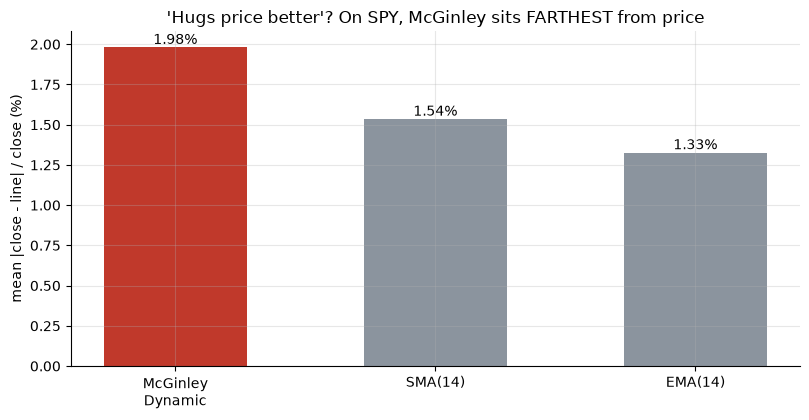

MD 1.981%  SMA 1.535%  EMA 1.327%


In [2]:
if HAVE_REAL:
    close = tape('SPY')['close']
    td = st.tracking_distance(close, n=MD_N)
else:
    td = {'MD': R['td_md'], 'SMA': R['td_sma'], 'EMA': R['td_ema']}
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['McGinley\nDynamic', 'SMA(14)', 'EMA(14)'], [td['MD'], td['SMA'], td['EMA']],
       color=[RED, GREY, GREY], width=.55)
for i, v in enumerate([td['MD'], td['SMA'], td['EMA']]):
    ax.annotate(f'{v:.2f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('mean |close - line| / close (%)')
ax.set_title("'Hugs price better'? On SPY, McGinley sits FARTHEST from price")
plt.tight_layout(); plt.show()
print(f"MD {td['MD']:.3f}%  SMA {td['SMA']:.3f}%  EMA {td['EMA']:.3f}%")

On 33 years of SPY, the McGinley line sits **1.98%** away from price on average — farther than the plain SMA (**1.53%**) and the EMA (**1.33%**). The line that's supposed to "hug price" is the loosest of the three. Here's why, on a clean example: a price that sits flat, then jumps 20% and stays there.

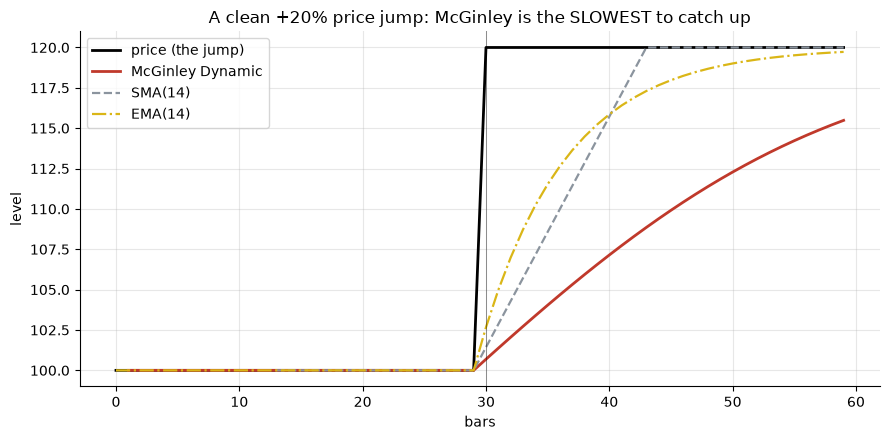

5 bars after the jump: MD closed 20% of the gap, SMA 43%, EMA 58%


In [3]:
sr = st.step_response(n=MD_N)
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(sr.index, sr['price'], c='k', lw=2, label='price (the jump)')
ax.plot(sr.index, sr['MD'], c=RED, lw=2, label='McGinley Dynamic')
ax.plot(sr.index, sr['SMA'], c=GREY, lw=1.6, ls='--', label='SMA(14)')
ax.plot(sr.index, sr['EMA'], c=AMBER, lw=1.6, ls='-.', label='EMA(14)')
ax.axvline(30, c='k', lw=.7, alpha=.4)
ax.set_xlabel('bars'); ax.set_ylabel('level')
ax.set_title('A clean +20% price jump: McGinley is the SLOWEST to catch up')
ax.legend(); plt.tight_layout(); plt.show()
print(f"5 bars after the jump: MD closed {R['step_pct_md']:.0f}% of the gap, "
      f"SMA {R['step_pct_sma']:.0f}%, EMA {R['step_pct_ema']:.0f}%")

Five bars after the jump, the plain EMA has closed **58%** of the gap and even the SMA has closed **43%** — the McGinley line has closed only **20%**. The `^4` brake fires hardest exactly when price is moving fastest — the opposite of "speeds up to keep pace." It's a real mechanism; it just runs backwards from the sales pitch.

**Now, does that brake at least mean fewer false trading signals?** Turn each line into a long/flat rule and count the switches.

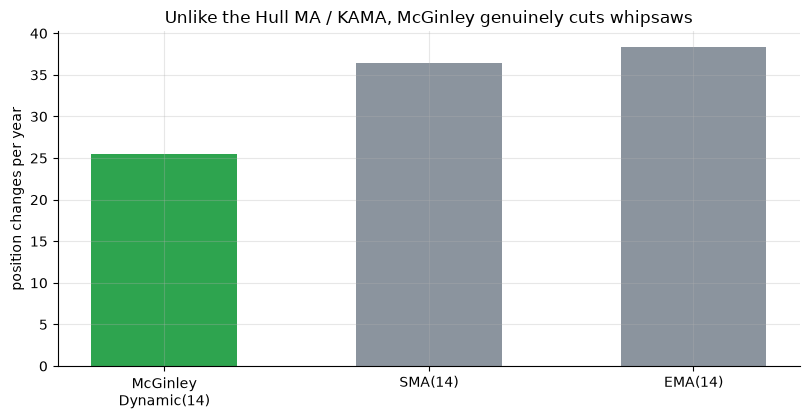

MD 25.5/yr  SMA 36.5/yr  EMA 38.3/yr


In [4]:
if HAVE_REAL:
    res = st.run_experiment(tape('SPY'), md_n=MD_N, sma_period=MD_N, ema_period=MD_N,
                            cost_bps=5.0)
    sw = {k: res[k]['switches_per_yr'] for k in ('MD','SMA','EMA')}
else:
    sw = dict(MD=R['md_sw'], SMA=R['sma_sw'], EMA=R['ema_sw'])
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['McGinley\nDynamic(14)', 'SMA(14)', 'EMA(14)'], [sw['MD'], sw['SMA'], sw['EMA']],
       color=[GREEN, GREY, GREY], width=.55)
ax.set_ylabel('position changes per year')
ax.set_title('Unlike the Hull MA / KAMA, McGinley genuinely cuts whipsaws')
plt.tight_layout(); plt.show()
print(f"MD {sw['MD']:.1f}/yr  SMA {sw['SMA']:.1f}/yr  EMA {sw['EMA']:.1f}/yr")

**25.5 switches/yr** vs the SMA's **36.5** and the EMA's **38.3** — roughly **30% fewer trades**. This is genuinely the opposite finding from the desk's other "smarter MA" teardowns, where lower lag bought *more* whipsaws. Here the brake resists noise, and fewer trades really do result. So — does reacting slower and trading less actually make money?

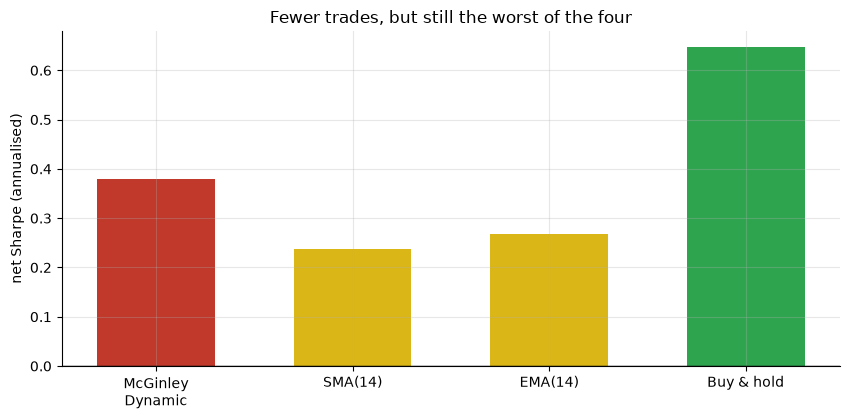

MD 0.380 | SMA 0.238 | EMA 0.267 | hold 0.647


In [5]:
if HAVE_REAL:
    fp, sp, ep = res['MD']['sharpe_net'], res['SMA']['sharpe_net'], res['EMA']['sharpe_net']
    bh = res['MD']['bh_sharpe']
else:
    fp, sp, ep, bh = R['md_sharpe'], R['sma_sharpe'], R['ema_sharpe'], R['bh_sharpe']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['McGinley\nDynamic', 'SMA(14)', 'EMA(14)', 'Buy & hold'], [fp, sp, ep, bh],
       color=[RED, AMBER, AMBER, GREEN], width=.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe (annualised)')
ax.set_title('Fewer trades, but still the worst of the four')
plt.tight_layout(); plt.show()
print(f'MD {fp:.3f} | SMA {sp:.3f} | EMA {ep:.3f} | hold {bh:.3f}')

No. Buy-and-hold (Sharpe **0.647**) still beats every timing rule, and McGinley Dynamic (**0.38**) — despite trading the least — is still below holding by a wide margin. Sitting out 30% of a bull market to avoid whipsaws is not free, and the avoided whipsaws didn't earn their keep.

## 5 · The verdict

- **Signal — None.** Active spread vs holding **-3.01 bps/day**, *t* = **-3.55** — negative on all five tapes tested and both halves of history.
- **Tradability — Mirage.** Net Sharpe **0.38** vs buy-and-hold **0.647**; loses even gross, and no cost level rescues it.
- **Cuts whipsaws & beats a plain MA? — Mixed.** **25.5** switches/yr vs the SMA's **36.5** — a real ~30% cut — but the line hugs price *worse*, not better, and the fewer trades only beat the SMA/EMA head-to-head on 3 of 10 basket checks.

## 6 · Could you actually trade it?

No. The gross timing already loses to holding; costs only widen the gap. No cost level tested finds a break-even:

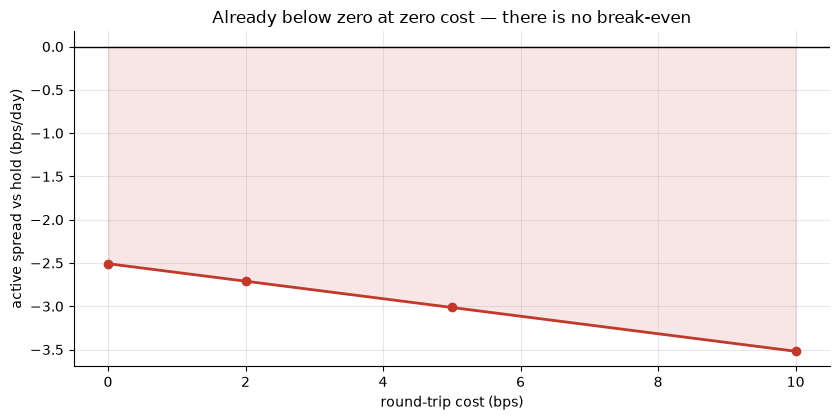

The gross spread is negative; costs are not the issue, the timing is.


In [6]:
if HAVE_REAL:
    costs = [0.0, 2.0, 5.0, 10.0]
    spr = [st.run_experiment(tape('SPY'), md_n=MD_N, cost_bps=c)['MD']['mean_spread_bps']
           for c in costs]
else:
    costs = [0.0, 2.0, 5.0, 10.0]; spr = [-2.51, -2.71, -3.01, -3.52]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, spr, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, spr, 0, color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('active spread vs hold (bps/day)')
ax.set_title('Already below zero at zero cost — there is no break-even')
plt.tight_layout(); plt.show()
print('The gross spread is negative; costs are not the issue, the timing is.')

## 7 · Going further

- **The positive control.** The companion notebook plants a real trend in a synthetic tape — and the *same* McGinley engine catches it cleanly (*t* up to +15). The harness works; the daily stock market just doesn't hand this rule an edge over the SMA/EMA it claims to beat, or over just holding.
- **A slower N, or weekly bars.** The brake mechanism might earn its keep at a longer horizon where the whipsaw cut has more room to compound — worth a fork.
- **Other 'smarter MA' claims, similar fate.** See [Study 432 (Hull MA)](../../432-hull-moving-average/), [Study 433 (KAMA)](../../433-kama-adaptive/) and [Study 434 (DEMA/TEMA)](../../434-dema-tema/) — none beats a plain SMA/EMA or holding, each for a different mechanistic reason.

*Think McGinley's brake earns its keep on a different timeframe, asset class or as a volatility filter rather than a timing signal? Fork this and show an active spread that clears HAC *t* = 2 against buy-and-hold. That's the bar.*